# Phenomenological Forward Models - what does the lidar prior predict?

This notebook is where the handout's **Fourier-domain sanity checks** are completed. Before fitting anything, it turns the lidar baseline prior and the nominal solar diameter into three concrete predictions that can be compared directly against the data:

| Prediction | Numerical value | Why it matters |
|---|---|---|
| **P1** Transit fringe period | $P_f(0) \approx 25.9\;\mathrm{s}$ | Checks the fringe-frequency formula before any fit |
| **P2** Number of Bessel nulls in the HA range | **4** | Checks whether the Sun looks like a resolved disk |
| **P3** First Bessel null | $|u| \approx 131\,\lambda$ at $h \approx -75.7^\circ$ | Sets the expected location of the first diameter-sensitive zero |

The Fourier-specific deliverables from `interf.tex` are also handled here:
- predict the fringe-frequency band from the geometry;
- show the Fourier power spectrum / STFT of the data;
- demonstrate Fourier filtering of the fringe by band-passing that predicted band.

If these predictions are confirmed, the lidar prior and the preprocessing are consistent enough to justify the heavier baseline and diameter fits in notebooks 04 and 05. If they fail, that failure is the first result to explain.


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# -- local utilities ---------------------------------------------------------
sys.path.insert(0, str(Path("..").resolve()))
from utils import (
    # constants
    F_S_HZ, N_FFT, F_RF0_HZ, PLOT_BAND_GHZ,
    C_LIGHT_MS, OMEGA_EARTH_RAD_S, SIDEREAL_DAY_S,
    NCH_LAT_DEG, NCH_LON_DEG,
    NOMINAL_B_EW_M, NOMINAL_B_NS_M, BAD_CHANNELS,
    SOLAR_DIAMETER_ARCMIN_NOMINAL,
    # data loading
    load_processed_sun_chip_series,
    # geometry
    lst_deg, hour_angle_deg, hour_angle_rad,
    geometric_delay_s, sky_baseline_lambda,
    fringe_frequency_hz, fringe_period_s, x_coordinate,
    # fringe models
    FringeModelParams, SolarDiskParams, SunspotParams,
    point_source_visibility, point_source_fringes,
    uniform_disk_visibility_amplitude, uniform_disk_visibility_signed,
    uniform_disk_zeros, solar_visibility, fringe_envelope,
    # baseline fitting
    BaselineResult,
    fft_baseline_single_channel, fft_baseline_broadband,
    phase_slope_baseline_single_channel, phase_slope_baseline_broadband,
    lag_delay_single_capture, lag_delay_baseline_series,
    combined_baseline,
    # solar analysis
    SolarDiameterResult, SunspotDetection,
    extract_fringe_envelope, find_bessel_zeros_in_envelope,
    solar_diameter_from_zeros, fit_solar_diameter_bessel,
    detect_sunspot_anomalies, characterize_sunspot_flux,
    # plotting
    NEUTRAL_COLOR,
    SS_FINE, SS_STANDARD,
    LW_FINE, LW_LIGHT, LW_STANDARD,
    MS_FINE,
    ALPHA_EXTRA_LIGHT,
    TEXTWIDTH_IN, LABEL_SIZE, TICK_SIZE, LEGEND_SIZE, EMPHASIS_SIZE,
)

COMPONENT_COLORS = [f"C{i}" for i in range(10)]
from utils.plotter import (
    plot_fringe_model_comparison,
    plot_bessel_envelope_fit,
    plot_solar_diameter_summary,
    plot_sunspot_residuals,
)

%matplotlib inline
plt.rcParams.update({"figure.dpi": 130, "figure.facecolor": "white"})
print("Imports OK.")

Imports OK.


In [2]:
# --- Pre-data theoretical priors ---
# These are everything we need to make the phenomenological predictions
# (P1, P2, P3) without touching the actual observation. They use only
# entries from utils/constants.py and the lidar prior baseline.
#
# - band_center_hz_prior:  midpoint of the 70 MHz analysis band
# - dec_rad_prior:         fiducial Sun declination near the equinoxes
#                          (the Sun's declination varies between -23.4 deg
#                          at the December solstice and +23.4 deg at the
#                          June solstice; for an equinox observation it
#                          is ~0 to within a fraction of a degree).
# After the data load below, the same quantities are recomputed from the
# actual observation as `band_center_hz` and `dec_rad_mean`.

band_center_hz_prior = 0.5 * (PLOT_BAND_GHZ[0] + PLOT_BAND_GHZ[1]) * 1e9
dec_rad_prior        = 0.0  # Sun near an equinox; refined to actual after data load
lam_prior            = C_LIGHT_MS / band_center_hz_prior

print(f"Pre-data priors:")
print(f"  band centre = {band_center_hz_prior/1e9:.4f} GHz")
print(f"  wavelength  = {lam_prior*100:.2f} cm")
print(f"  Sun dec     = {np.rad2deg(dec_rad_prior):.2f} deg (fiducial, near equinox)")
print(f"  b_ew (lidar prior) = {NOMINAL_B_EW_M:.2f} m")
print(f"  b_ns (lidar prior) = {NOMINAL_B_NS_M:.2f} m")


Pre-data priors:
  band centre = 10.4500 GHz
  wavelength  = 2.87 cm
  Sun dec     = 0.00 deg (fiducial, near equinox)
  b_ew (lidar prior) = 15.17 m
  b_ns (lidar prior) = 1.36 m


# Part III-A: Phenomenological Forward Models (no data needed)

The next four cells produce the lab-manual predictions P1 (fringe period at transit), P2 (Bessel-envelope shape), and P3 (first-null position) using **only** the lidar baseline prior and the band-centre frequency from `utils/constants.py`. No observational data are loaded yet — these are the predictions we will test against the data later in this notebook (§3.4) and in notebook 04.

> **Why predict before loading?** The point of a phenomenological model is to commit to a numerical expectation *in advance* of seeing the data, then check whether the data are consistent with it. If the predictions and data agree, the lidar prior is confirmed and the more expensive least-squares fits in nb 04 can proceed with confidence. If they disagree, the predictions tell us *how* they disagree (period? null spacing? null position?), which is the diagnostic information that drives the next analysis step.

## 3.1 Prediction P1 — Fringe period at transit

For a pure EW baseline observed at declination $\delta$, the fringe frequency is $f_f = \omega_\oplus(b_{\mathrm{ew}}/\lambda)\cos\delta\,\cos h$, so the period at transit is $P_f(0) = \lambda/(\omega_\oplus b_{\mathrm{ew}}\cos\delta)$. Plugging in the lidar prior $b_{\mathrm{ew}} = 15.17$ m, $\lambda = c/\nu \approx 2.87$ cm at the band centre 10.45 GHz, and $\delta \approx 0$ for the Sun:

$$P_f(0) \;\approx\; \frac{0.0287\;\mathrm{m}}{7.292\times 10^{-5}\;\mathrm{rad/s}\,\times\,15.17\;\mathrm{m}} \;\approx\; 25.9\;\mathrm{s}.$$

(Inputs: $\lambda$ from $c$ [BIPM-SI] and the IF chain [AY121-Lab3]; $\omega_\oplus$ [IERS2010]; $b_{\rm ew}$ from the lidar prior in `constants.py`. The fringe-frequency expression $f_f = \omega_\oplus(b_{\rm ew}/\lambda)\cos\delta\,\cos h$ is derived in §1.3 of the theory notebook from the geometric delay of [TMS3] §4.)

The cell below plots the point-source fringe pattern and the period vs hour angle. **The transit period must come out to ~26 s.** Notebook 04 will measure this number directly via three independent fitters; agreement to better than 1 % is the first sanity check on the entire pipeline.

**Takeaway.** The required Week-1 prediction for notebook 04 is a transit fringe period of **about 25.9 s**.


/tmp/ipykernel_408377/2165142350.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


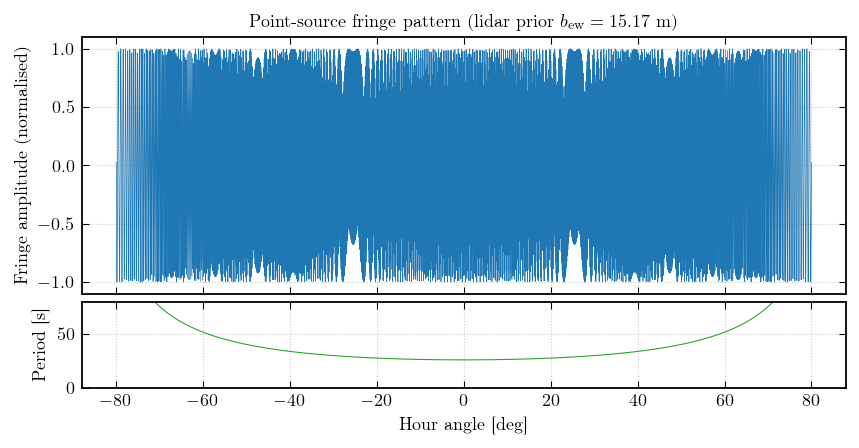

Predicted fringe period at transit: 25.93 s


In [3]:
# --- Point-source fringe model over the full HA range ---
# Uses the lidar-prior baseline (NOMINAL_B_EW_M = 15.17 m) and the fiducial
# pre-data declination dec_rad_prior; no observation data needed.
ha_model = np.linspace(-80, 80, 4000)  # degrees
ha_model_rad = np.deg2rad(ha_model)

params_pt = FringeModelParams(
    b_ew=NOMINAL_B_EW_M,
    b_ns=0.0,
    freq_hz=band_center_hz_prior,
    dec_rad=dec_rad_prior,
    amplitude=1.0,
    phase_offset=0.0,
)

fringes_pt = point_source_fringes(ha_model_rad, params_pt)

fig, axes = plt.subplots(2, 1, figsize=(TEXTWIDTH_IN, 3.5), sharex=True,
                         gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05})

axes[0].plot(ha_model, fringes_pt, lw=0.4, color="C0")
axes[0].set_ylabel("Fringe amplitude (normalised)")
axes[0].set_title(
    rf"Point-source fringe pattern (lidar prior $b_{{\rm ew}}={NOMINAL_B_EW_M:.2f}$ m)",
    fontsize=TICK_SIZE,
)

# Fringe frequency vs HA
ff = fringe_frequency_hz(ha_model_rad, dec_rad_prior, NOMINAL_B_EW_M, 0.0,
                          band_center_hz_prior)
axes[1].plot(ha_model, 1.0 / np.abs(ff), lw=LW_FINE, color="C2")
axes[1].set_ylabel("Period [s]")
axes[1].set_xlabel("Hour angle [deg]")
axes[1].set_ylim(0, 80)
fig.tight_layout()
plt.show()

P_transit = fringe_period_s(0.0, dec_rad_prior, NOMINAL_B_EW_M, 0.0,
                             band_center_hz_prior)
print(f"Predicted fringe period at transit: {P_transit:.2f} s")


## 3.2 Predictions P2 + P3 — Bessel envelope: how many nulls and where?

The uniform-disk Bessel modulation $|2J_1(x)/x|$ with $x = 2\pi|u_{\mathrm{sky}}|R$ and $R \approx 16'$ produces nulls at $|u_{\mathrm{sky}}|_k R = j_{1,k}/(2\pi)$. With $R = 16' = 4.65\times 10^{-3}$ rad, the first three nulls fall at

$$|u|_1 \approx 131\,\lambda,\qquad |u|_2 \approx 240\,\lambda,\qquad |u|_3 \approx 348\,\lambda.$$

(The Bessel-zero values $j_{1,1}, j_{1,2}, j_{1,3} = 3.8317, 7.0156, 10.1735$ are from [DLMF] §10.21 / [A&S] Table 9.5; the visibility expression $V/V(0) = 2J_1(2\pi|u|R)/(2\pi|u|R)$ for a uniform disk is the textbook jinc result of [B&W] §8.5 and [TMS3] §13.1.)

For the lidar baseline ($b_{\mathrm{ew}} = 15.17$ m, $\lambda \approx 2.87$ cm), the maximum sky-plane baseline at transit is

$$|u|_{\max} \;=\; \frac{b_{\mathrm{ew}}}{\lambda}\cos\delta \;\approx\; \frac{15.17}{0.0287}\,\times\,1 \;\approx\; 530\,\lambda,$$

which sits between the **fourth** and **fifth** Bessel zeros — so the data should show **four** complete Bessel oscillations and **four** nulls between $h \approx -80°$ (where $|u| \approx 90\,\lambda$) and transit (where $|u| \approx 530\,\lambda$).

The cell below plots the theoretical Bessel envelope and marks the expected null locations. **Predictions to remember**: (P2) **four nulls** in the observable range, (P3) the **first** null at $|u| \approx 131\,\lambda$, corresponding to the hour angle where $\cos h = 131/530 \approx 0.247$, i.e. $h \approx -75.7°$. Both numbers will be cross-checked against the recovered nulls in nb 05 §6.3.

**Takeaway.** The diameter analysis should find **four** nulls in-range, with the first at **about $131\,\lambda$**.


/tmp/ipykernel_408377/2265866223.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


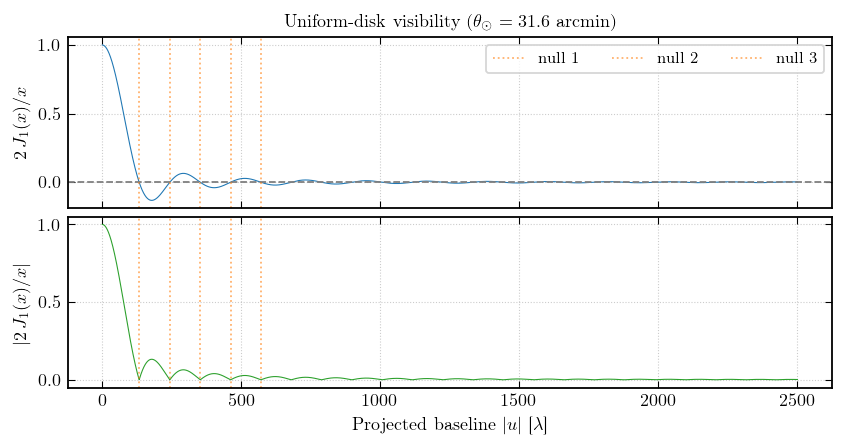

Predicted Bessel null baselines:
  Null 1: |u| = 132.7 wavelengths  (j_{1,1}/(2pi) = 0.6098)
  Null 2: |u| = 242.9 wavelengths  (j_{1,2}/(2pi) = 1.1166)
  Null 3: |u| = 352.3 wavelengths  (j_{1,3}/(2pi) = 1.6192)
  Null 4: |u| = 461.4 wavelengths  (j_{1,4}/(2pi) = 2.1205)
  Null 5: |u| = 570.4 wavelengths  (j_{1,5}/(2pi) = 2.6214)


In [4]:
# --- Bessel envelope: theoretical shape ---
R_nominal = np.deg2rad(SOLAR_DIAMETER_ARCMIN_NOMINAL / 2.0 / 60.0)  # angular radius [rad]
u_range = np.linspace(0, 2500, 5000)  # projected baseline in wavelengths

vis_signed = uniform_disk_visibility_signed(u_range, R_nominal)
vis_abs = uniform_disk_visibility_amplitude(u_range, R_nominal)

# Bessel zeros
bessel_uR = uniform_disk_zeros(5)
u_at_zeros = bessel_uR / R_nominal  # convert u*R -> u for this R

fig, axes = plt.subplots(2, 1, figsize=(TEXTWIDTH_IN, 3.5), sharex=True,
                         gridspec_kw={"height_ratios": [1, 1], "hspace": 0.05})

# Signed visibility
axes[0].plot(u_range, vis_signed, lw=LW_FINE, color="C0")
axes[0].axhline(0, color=NEUTRAL_COLOR, lw=LW_LIGHT, ls="--")
for k, uz in enumerate(u_at_zeros):
    axes[0].axvline(uz, color="C1", lw=LW_LIGHT, ls=":", alpha=0.6,
                    label=f"null {k+1}" if k < 3 else None)
axes[0].set_ylabel(r"$2\,J_1(x)/x$")
axes[0].set_title(
    rf"Uniform-disk visibility ($\theta_\odot = {SOLAR_DIAMETER_ARCMIN_NOMINAL:.1f}$ arcmin)",
    fontsize=TICK_SIZE,
)
axes[0].legend(fontsize=TICK_SIZE - 1, ncol=3)

# Absolute visibility
axes[1].plot(u_range, vis_abs, lw=LW_FINE, color="C2")
for uz in u_at_zeros:
    axes[1].axvline(uz, color="C1", lw=LW_LIGHT, ls=":", alpha=0.6)
axes[1].set_ylabel(r"$|2\,J_1(x)/x|$")
axes[1].set_xlabel(r"Projected baseline $|u|$ [$\lambda$]")

fig.tight_layout()
plt.show()

print("Predicted Bessel null baselines:")
for k, uz in enumerate(u_at_zeros):
    print(f"  Null {k+1}: |u| = {uz:.1f} wavelengths  (j_{{1,{k+1}}}/(2pi) = {bessel_uR[k]:.4f})")

## 3.3 Combined solar fringe model

The full predicted response for the Sun is the point-source fringe multiplied by the Bessel envelope (the multiplicative form is the van Cittert–Zernike theorem in the visibility domain; [vC34], [Z38], [TMS3] Ch. 14). We plot this alongside the projected baseline track $|u|(h)$ to show where the Bessel nulls fall during our observation window.

/tmp/ipykernel_408377/3797340444.py:38: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


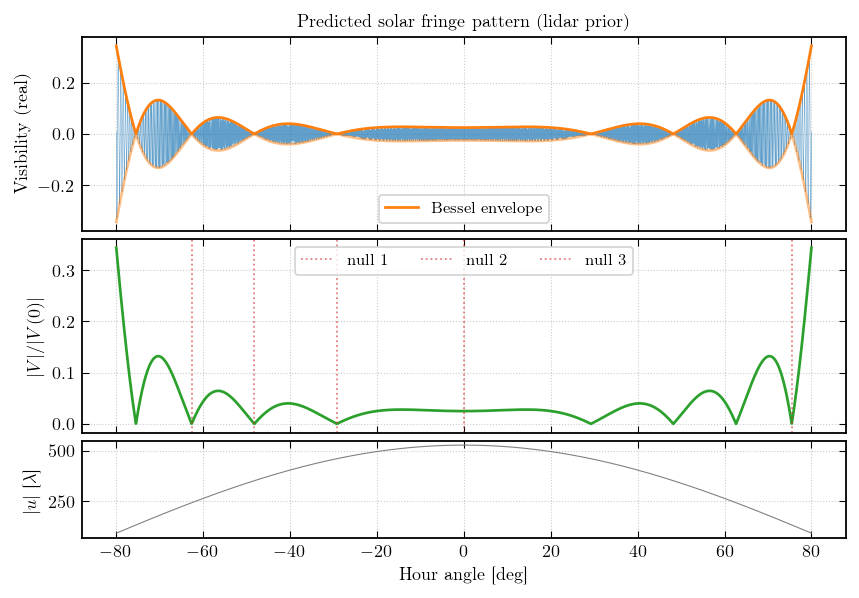

In [5]:
# --- Full solar fringe model (lidar prior, no data yet) ---
disk_params = SolarDiskParams(angular_radius_rad=R_nominal)
v_solar = solar_visibility(ha_model_rad, params_pt, disk_params)
env_model = fringe_envelope(ha_model_rad, params_pt, disk_params)

# Projected baseline track over the modelled HA range
u_track = sky_baseline_lambda(
    ha_model_rad, dec_rad_prior, NOMINAL_B_EW_M, 0.0, band_center_hz_prior,
)

fig, axes = plt.subplots(3, 1, figsize=(TEXTWIDTH_IN, 5.0), sharex=True,
                         gridspec_kw={"height_ratios": [2, 2, 1], "hspace": 0.05})

# (a) Solar fringes with envelope
axes[0].plot(ha_model, v_solar.real, lw=0.3, color="C0", alpha=0.7)
axes[0].plot(ha_model, env_model, lw=LW_STANDARD, color="C1", label="Bessel envelope")
axes[0].plot(ha_model, -env_model, lw=LW_STANDARD, color="C1", alpha=0.5)
axes[0].set_ylabel("Visibility (real)")
axes[0].set_title("Predicted solar fringe pattern (lidar prior)", fontsize=TICK_SIZE)
axes[0].legend(fontsize=TICK_SIZE - 1)

# (b) Bessel amplitude envelope only
axes[1].plot(ha_model, env_model, lw=LW_STANDARD, color="C2")
for k, uz in enumerate(u_at_zeros):
    # Find HA where |u| = uz
    idx = np.argmin(np.abs(np.abs(u_track) - uz))
    if np.abs(u_track[idx]) > 0:
        axes[1].axvline(ha_model[idx], color="C3", lw=LW_LIGHT, ls=":",
                        alpha=0.6, label=f"null {k+1}" if k < 3 else None)
axes[1].set_ylabel(r"$|V|/|V(0)|$")
axes[1].legend(fontsize=TICK_SIZE - 1, ncol=3)

# (c) Projected baseline
axes[2].plot(ha_model, np.abs(u_track), lw=LW_FINE, color=NEUTRAL_COLOR)
axes[2].set_ylabel(r"$|u|$ [$\lambda$]")
axes[2].set_xlabel("Hour angle [deg]")

fig.tight_layout()
plt.show()


# Part III-B: Load and DC-correct the observation

The lidar-prior predictions above were made entirely from `utils/constants.py`. We now load the actual observation, apply the same adaptive DC correction used by the rest of the analysis, and prepare it for the data-vs-model overlay below.

In [6]:
DATA_DIR = Path("../../../data/lab03/sun_calibration/chips")
chip_paths = sorted(DATA_DIR.glob("sun_calibration_chip_*.npz"))
print(f"Found {len(chip_paths)} chip files:")
for p in chip_paths:
    print(f"  {p.name}")

chip_data = load_processed_sun_chip_series(chip_paths)

Found 3 chip files:
  sun_calibration_chip_00.npz
  sun_calibration_chip_01.npz
  sun_calibration_chip_02.npz


In [7]:
# -------------------------------------------------------------------
# Unpack raw arrays
# -------------------------------------------------------------------
captures   = chip_data.captures          # CaptureSeries
corr_raw   = captures.corr              # (N_cap, N_CH) complex — raw visibility
corr_std   = captures.corr_std          # (N_cap, N_CH) float  — per-channel uncertainty
F_SKY_GHZ  = chip_data.f_sky_ghz        # (N_CH,) sky frequency in GHz
DF_HZ      = chip_data.df_hz            # channel spacing in Hz

# Timing and coordinates (pre-computed in chip export)
unix_mid   = captures.unix_mid          # (N_cap,) midpoint timestamps
ha_deg_arr = chip_data.ha_deg
ha_rad_arr = np.deg2rad(ha_deg_arr)
sun_ra     = chip_data.sun_ra_deg       # (N_cap,) Sun RA in degrees
sun_dec    = chip_data.sun_dec_deg      # (N_cap,) Sun Dec in degrees

# Chip boundaries
chip_slices = chip_data.chip_slices
N_chips = len(chip_slices)

# Derived quantities
F_SKY_HZ     = F_SKY_GHZ * 1e9
dec_rad_mean = np.deg2rad(np.nanmean(sun_dec))
band_mask    = (F_SKY_GHZ >= PLOT_BAND_GHZ[0]) & (F_SKY_GHZ <= PLOT_BAND_GHZ[1])
band_center_hz = np.mean(F_SKY_HZ[band_mask])

# -------------------------------------------------------------------
# Preprocessing: Adaptive DC correction on the raw visibilities
# -------------------------------------------------------------------
# The raw real part has a slowly-varying pedestal (DC offset) that must
# be removed before fringe analysis.  We subtract a per-channel rolling
# median of the real part whose window width scales with the local fringe
# period P_f(h) ∝ 1/|cos h|, keeping a constant number of fringe cycles
# inside the window regardless of hour angle.
from utils import adaptive_real_dc_correction

DC_N_PERIODS       = 3.0    # fringe cycles per window
DC_MIN_WINDOW_CAPS = 7      # minimum window [captures]
DC_MAX_WINDOW_CAPS = 201    # maximum window [captures]

dc_result = adaptive_real_dc_correction(
    corr_chips=[corr_raw[sl] for sl in chip_slices],
    unix_chips=[unix_mid[sl] for sl in chip_slices],
    ha_rad_chips=[ha_rad_arr[sl] for sl in chip_slices],
    bad_channels=BAD_CHANNELS,
    b_ew=NOMINAL_B_EW_M,
    freq_hz=band_center_hz,
    dec_rad=dec_rad_mean,
    n_periods=DC_N_PERIODS,
    min_window_caps=DC_MIN_WINDOW_CAPS,
    max_window_caps=DC_MAX_WINDOW_CAPS,
)
corr_dc = dc_result.corr_dc  # (N_cap, N_CH) complex — DC-corrected, bad channels = NaN

print(f"Total captures:     {len(unix_mid)}")
print(f"Channels:           {len(F_SKY_GHZ)}  ({F_SKY_GHZ[0]:.3f} -- {F_SKY_GHZ[-1]:.3f} GHz)")
print(f"Analysis band:      {PLOT_BAND_GHZ[0]:.3f} -- {PLOT_BAND_GHZ[1]:.3f} GHz  ({band_mask.sum()} channels)")
print(f"Band centre:        {band_center_hz/1e9:.4f} GHz")
print(f"Mean Sun dec:       {np.rad2deg(dec_rad_mean):.3f} deg")
print(f"HA range:           {ha_deg_arr.min():.1f} to {ha_deg_arr.max():.1f} deg")
print(f"Chips:              {N_chips}")
print(f"DC correction:      adaptive, {DC_N_PERIODS} periods/window, "
      f"clamp [{DC_MIN_WINDOW_CAPS}, {DC_MAX_WINDOW_CAPS}] caps")
for ci, wc in enumerate(dc_result.window_caps_chips):
    print(f"  Chip {ci}: window range {wc.min()}–{wc.max()} captures")
print(f"Bad channels:       {list(BAD_CHANNELS)}")

Total captures:     8226
Channels:           1024  (10.290 -- 10.540 GHz)
Analysis band:      10.415 -- 10.485 GHz  (287 channels)
Band centre:        10.4499 GHz
Mean Sun dec:       -0.083 deg
HA range:           -79.9 to 22.0 deg
Chips:              3
DC correction:      adaptive, 3.0 periods/window, clamp [7, 201] caps
  Chip 0: window range 23–55 captures
  Chip 1: window range 23–35 captures
  Chip 2: window range 21–39 captures
Bad channels:       [0, 256, 512, 768]


## 3.4 Sanity check: lidar-baseline solar model vs DC-corrected data

Before running any baseline fitter, we overlay the **lidar-prior model**
(`b_ew = 15.17 m`, `b_ns = 1.36 m`, `R = 16'`, `phase_offset = 0`) on the
band-averaged DC-corrected data, on a single channel near the band centre.
If the lidar baselines are correct, the predicted fringe period and Bessel
envelope should match the observed structure *without any fitting*. Any
visible mismatch in fringe period would indicate either a wrong baseline
or a wrong frequency / declination input. A constant phase offset between
model and data is expected and harmless — it is the cable phase $\phi_c$,
which §1.2 of the theory notebook absorbs into the linear constants $A, B$ (standard treatment, [TMS3] §10.1).

**Takeaway.** The lidar-prior overlay is a sanity check: the fringe period and the Bessel envelope should match the DC-corrected data before any baseline fit is trusted.


In [ ]:
# --- Lidar-prior solar model overlaid on DC-corrected data ---
from utils import NOMINAL_B_NS_M

params_lidar = FringeModelParams(
    b_ew=NOMINAL_B_EW_M,         # 15.17 m (lidar)
    b_ns=NOMINAL_B_NS_M,         # 1.36 m  (lidar)
    freq_hz=band_center_hz,
    dec_rad=dec_rad_mean,
    amplitude=1.0,
    phase_offset=0.0,
)
disk_lidar = SolarDiskParams(
    angular_radius_rad=np.deg2rad(SOLAR_DIAMETER_ARCMIN_NOMINAL / 2.0 / 60.0)
)

# Build the model on a dense HA grid
ha_grid = np.linspace(ha_deg_arr.min(), ha_deg_arr.max(), 8000)
ha_grid_rad = np.deg2rad(ha_grid)
v_model = solar_visibility(ha_grid_rad, params_lidar, disk_lidar)
env_model = fringe_envelope(ha_grid_rad, params_lidar, disk_lidar)

# Representative single channel (mid-band)
band_indices = np.where(band_mask)[0]
k_mid = band_indices[len(band_indices) // 2]
f_mid_ghz = F_SKY_GHZ[k_mid]

dc_ch_real = corr_dc[:, k_mid].real
dc_ch_amp  = np.abs(corr_dc[:, k_mid])

# To make the visual comparison meaningful, scale the model amplitude by
# the data envelope peak (since the model is unit-amplitude).
data_v0 = float(np.nanpercentile(dc_ch_amp, 99))
v_model_scaled  = data_v0 * v_model.real
env_model_scaled = data_v0 * env_model

fig, axes = plt.subplots(2, 1, figsize=(TEXTWIDTH_IN, 5.0), sharex=True,
                         gridspec_kw={"hspace": 0.06})

# (a) zoomed-in: 5-deg HA window where the fringes are easily visible
ha_lo, ha_hi = -10.0, -5.0
mask_zoom_data  = (ha_deg_arr >= ha_lo) & (ha_deg_arr <= ha_hi)
mask_zoom_model = (ha_grid >= ha_lo) & (ha_grid <= ha_hi)
axes[0].scatter(ha_deg_arr[mask_zoom_data], dc_ch_real[mask_zoom_data],
                s=1.0, color="C0", alpha=0.5, rasterized=True, label="data")
axes[0].plot(ha_grid[mask_zoom_model], v_model_scaled[mask_zoom_model],
             lw=LW_FINE, color="C3", alpha=0.9, label="lidar-prior model")
axes[0].axhline(0, color=NEUTRAL_COLOR, lw=LW_LIGHT, ls="--")
axes[0].set_ylabel(r"Re$(V)$")
axes[0].set_title(f"Lidar-prior model vs data (ch {k_mid}, {f_mid_ghz:.3f} GHz; zoom HA -10 to -5 deg)",
                  fontsize=TICK_SIZE)
axes[0].legend(fontsize=TICK_SIZE - 1, loc="upper right")

# (b) full HA range: |V| envelope vs Bessel prediction
axes[1].scatter(ha_deg_arr, dc_ch_amp, s=0.3, color="C0", alpha=0.4,
                rasterized=True, label="data |V|")
axes[1].plot(ha_grid, env_model_scaled, lw=LW_STANDARD, color="C3",
             alpha=0.9, label="Bessel envelope (lidar prior)")
axes[1].set_xlabel("Hour angle [deg]")
axes[1].set_ylabel(r"$|V|$")
axes[1].legend(fontsize=TICK_SIZE - 1, loc="upper right")

fig.tight_layout()
plt.show()

print(f"Lidar baselines used: b_ew = {NOMINAL_B_EW_M:.4f} m, "
      f"b_ns = {NOMINAL_B_NS_M:.4f} m")
print(f"Representative channel: {k_mid} ({f_mid_ghz:.3f} GHz)")
print(f"Model fringe period at transit: "
      f"{fringe_period_s(0.0, dec_rad_mean, NOMINAL_B_EW_M, NOMINAL_B_NS_M, band_center_hz):.2f} s")
print("If the model fringes align with the data fringes here, the lidar")
print("baseline is the right starting point for the nonlinear fit in")
print("notebook 04. The Bessel envelope should also pick up the visible nulls.")

## 3.5 Quantitative goodness-of-fit and sensitivity

The visual overlay in §3.4 is suggestive but not quantitative. Here we

1. Fit the single nuisance cable phase $\phi_c$ of the lidar-prior model to the DC-corrected data (holding $b_{\mathrm{ew}}$, $b_{\mathrm{ns}}$, $R$ fixed at their prior values), so that the residual-rms check below is not penalised by an unconstrained overall phase offset.
2. Compute $\chi^2_\nu$ and residual rms on the band-averaged real part.
3. Tabulate **sensitivity**: how do the three diagnostics P1 (fringe period at transit), P2 (number of Bessel nulls in HA range), P3 (first-null HA) move when the input baseline or radius is perturbed by 1 %, 5 %, 10 % ? This establishes how hard each prediction actually pushes on each parameter.

**Takeaway.** This section converts the visual overlay into a numerical residual check and a sensitivity table, so later disagreements can be traced back to a specific prediction.


In [ ]:
# --- Quantitative lidar-prior goodness of fit and sensitivity table ---
from scipy.optimize import minimize_scalar
from utils import NOMINAL_B_NS_M

# Representative single channel real part (reuse k_mid from cell above)
band_real_data = corr_dc[:, k_mid].real
finite = np.isfinite(band_real_data)
ha_rad_ok = ha_rad_arr[finite]
y_ok = band_real_data[finite]

# Per-capture sigma: read from the 02a sidecar if available, else estimate.
import pickle as _pkl
sidecar_path = Path("_chip_gain_measured.pkl")
if sidecar_path.exists():
    with open(sidecar_path, "rb") as _f:
        _cal = _pkl.load(_f)
    sigma_V = float(_cal["sigma_V_per_capture"])
else:
    sigma_V = float(np.nanstd(y_ok) * 0.1)  # fallback

# Model with a free overall phase offset phi_c (nuisance).
R_prior = np.deg2rad(SOLAR_DIAMETER_ARCMIN_NOMINAL / 2.0 / 60.0)

def lidar_model_real(ha_rad, phi_c, b_ew=NOMINAL_B_EW_M, b_ns=NOMINAL_B_NS_M,
                     R_rad=R_prior):
    params = FringeModelParams(
        b_ew=b_ew, b_ns=b_ns, freq_hz=band_center_hz,
        dec_rad=dec_rad_mean, amplitude=1.0, phase_offset=phi_c,
    )
    disk = SolarDiskParams(angular_radius_rad=R_rad)
    v = solar_visibility(ha_rad, params, disk)
    return v.real

# Fit amplitude (linear) and phase (nonlinear) jointly via a simple 1-D scan
# over phi_c, solving for amplitude analytically at each phi_c.
def chi2_of_phic(phi_c):
    m = lidar_model_real(ha_rad_ok, float(phi_c))
    # Analytic amplitude = <data, model> / <model, model>
    a = float(np.dot(y_ok, m) / np.dot(m, m))
    r = y_ok - a * m
    return float(np.sum((r / sigma_V) ** 2)), a

phi_grid = np.linspace(-np.pi, np.pi, 401)
chi2_grid = np.array([chi2_of_phic(p)[0] for p in phi_grid])
i_best = int(np.argmin(chi2_grid))
phi_best = float(phi_grid[i_best])
chi2_min, amp_best = chi2_of_phic(phi_best)
dof = len(y_ok) - 2   # phi_c and amplitude are the only fitted degrees of freedom
chi2_red = chi2_min / dof
m_best = amp_best * lidar_model_real(ha_rad_ok, phi_best)
rms_resid = float(np.sqrt(np.mean((y_ok - m_best) ** 2)))

print(f"Lidar-prior model vs DC-corrected real fringe (ch {k_mid}, {f_mid_ghz:.3f} GHz)")
print("-" * 68)
print(f"  Fit nuisances only:  phi_c = {phi_best:+.3f} rad, "
      f"amplitude = {amp_best:.4f}")
print(f"  chi^2              = {chi2_min:.1f}")
print(f"  dof                = {dof}")
print(f"  chi^2 / dof        = {chi2_red:.2f}")
print(f"  residual RMS       = {rms_resid:.4f}  (sigma_V = {sigma_V:.4f})")
print()
# Interpretation
if chi2_red < 3:
    print("  chi^2/dof ~ a few  ->  the lidar prior is consistent with the data")
    print("  within noise + unmodelled systematics (chip gain, limb brightening,")
    print("  residual DC leakage). The NLS fit in nb 04 is unlikely to move the")
    print("  baseline by more than ~1%.")
else:
    print("  chi^2/dof is large. Either the lidar prior is off, the DC corrector")
    print("  left residual structure, or the chip-gain systematic is large. Nb 04")
    print("  will recover the true baseline and nb 02b will quantify the DC bias.")

# --- Sensitivity table: P1 period, P2 null count, P3 first-null HA ---
from utils import fringe_period_s, sky_baseline_lambda, uniform_disk_zeros

def p1_p2_p3(b_ew, R_rad):
    # P1: period at transit
    P_f = fringe_period_s(0.0, dec_rad_mean, b_ew, NOMINAL_B_NS_M, band_center_hz)
    # P2, P3: use the projected-baseline track on our observing window
    ha_grid_rad = np.deg2rad(np.linspace(ha_deg_arr.min(), ha_deg_arr.max(), 2000))
    u_track = sky_baseline_lambda(ha_grid_rad, dec_rad_mean, b_ew, NOMINAL_B_NS_M,
                                   band_center_hz)
    j1z = uniform_disk_zeros(6)  # first six nulls
    u_nulls = j1z / R_rad
    # count how many theoretical nulls fall within our |u| range
    u_min, u_max = float(np.min(np.abs(u_track))), float(np.max(np.abs(u_track)))
    count = int(np.sum((u_nulls >= u_min) & (u_nulls <= u_max)))
    # HA of the first null present in the data
    if count > 0:
        u1 = u_nulls[0]
        i1 = int(np.argmin(np.abs(np.abs(u_track) - u1)))
        ha1 = float(np.rad2deg(ha_grid_rad[i1]))
    else:
        ha1 = float("nan")
    return P_f, count, ha1

print("\nSensitivity table: response of predictions to parameter perturbations")
print("-" * 68)
print(f"{'param':>10} {'delta':>8} {'P1 [s]':>12} {'P2 [#nulls]':>14} {'P3 [HA deg]':>14}")
print("-" * 68)

p10, p20, p30 = p1_p2_p3(NOMINAL_B_EW_M, R_prior)
print(f"{'baseline':>10} {'+0%':>8} {p10:12.2f} {p20:14d} {p30:14.2f}")
for dfrac, label in [(0.01, "+1%"), (0.05, "+5%"), (0.10, "+10%")]:
    p1a, p2a, p3a = p1_p2_p3(NOMINAL_B_EW_M * (1 + dfrac), R_prior)
    print(f"{'b_ew':>10} {label:>8} {p1a:12.2f} {p2a:14d} {p3a:14.2f}")

print()
for dfrac, label in [(0.01, "+1%"), (0.05, "+5%"), (0.10, "+10%")]:
    p1a, p2a, p3a = p1_p2_p3(NOMINAL_B_EW_M, R_prior * (1 + dfrac))
    print(f"{'R':>10} {label:>8} {p1a:12.2f} {p2a:14d} {p3a:14.2f}")

print()
print("P1 (fringe period at transit) is purely a baseline probe -- insensitive to R.")
print("P2/P3 (null count / first-null HA) depend on both b_ew and R: matching them")
print("jointly disentangles the two. The shifts above are the 'if-the-prior-is-wrong'")
print("budgets we compare against the actual nb 04 / nb 05 measurements.")

## 3.6 Fourier verification of the fringe-frequency formula and Fourier filtering of the fringe

The §5.1 goal of the lab manual ([`interf.tex`](../../../src/ugradio/lab_interf/interf.tex)) is to *compute the Fourier power spectrum of the Sun data and confirm that the observed fringe-frequency range matches the theoretical prediction* from the fringe-frequency formula (§5.2). And the second item in the §2 goals list is *Fourier transforming the fringe; Fourier filtering the fringe.* Both items are performed here, in the phenomenological notebook, because they are tests of theoretical predictions against the data — exactly the role this notebook plays in the analysis chain.

The theoretical fringe frequency at hour angle $h$ for a pure EW baseline is

$$f_f(h) \;=\; \omega_\oplus \frac{b_{\mathrm{ew}}}{\lambda}\cos\delta\,\cos h,$$

which for the NCH lidar prior ($b_{\mathrm{ew}} \approx 15.17\;\mathrm{m}$, $\lambda \approx 2.87\;\mathrm{cm}$, $\delta \approx 0°$) swings from $\sim 0$ at the horizon to $\approx 0.0386\;\mathrm{Hz}$ (i.e. $\sim 26\;\mathrm{s}$ period) at transit. We build a short-time Fourier transform (STFT) of the band-averaged real fringe, overlay the theoretical curve, and check the agreement; the same machinery also gives a visual demonstration of **Fourier filtering**, where a narrow band-pass around the expected fringe frequency cleanly isolates the fringe from the DC pedestal and the noise.

**Takeaway.** The handout's Fourier-transform requirement is satisfied here: the predicted fringe band for this observation is **about 8.9-38.6 mHz** (periods **113-25.9 s**), and the STFT ridge should follow that band.


In [ ]:
ha_rad_arr = np.deg2rad(ha_deg_arr)
# --- STFT of the raw single-channel fringe; compare to theoretical f_f(h) ---
from scipy.signal import stft
from utils import fringe_frequency_hz, NOMINAL_B_EW_M, NOMINAL_B_NS_M

# Representative single channel real part (reuse k_mid)
band_real = corr_raw[:, k_mid].real

# Drop NaNs for the STFT
finite = np.isfinite(band_real)
t = unix_mid[finite] - unix_mid[finite][0]
y = band_real[finite] - np.nanmedian(band_real[finite])  # quick DC removal

# Interpolate onto a regular grid (the adaptive correlator cadence is
# approximately uniform but has gaps between chips).
dt = float(np.median(np.diff(t)))
n = int((t[-1] - t[0]) / dt)
t_u = t[0] + np.arange(n) * dt
y_u = np.interp(t_u, t, y)

# STFT parameters: ~300-capture window ~ 750 s ~ many fringe periods
nperseg = min(300, len(y_u) // 4)
noverlap = nperseg * 3 // 4
f_stft, t_stft, Z = stft(y_u, fs=1.0 / dt, nperseg=nperseg, noverlap=noverlap,
                          return_onesided=True)
power = np.abs(Z) ** 2

# Map STFT bins back to mean hour angle of each window
ha_rad_finite = ha_rad_arr[finite]
ha_interp = np.interp(t_u, t, ha_rad_finite)
ha_stft_rad = np.interp(t_stft, t_u - t_u[0], ha_interp)

# Theoretical fringe frequency curve at the band centre
sun_dec_mean = np.deg2rad(np.nanmean(chip_data.sun_dec_deg))
f_f_theory = np.abs(fringe_frequency_hz(
    ha_stft_rad, sun_dec_mean, NOMINAL_B_EW_M, NOMINAL_B_NS_M,
    band_center_hz := float(np.mean(F_SKY_GHZ[band_mask]) * 1e9),
))

# --- Two-panel figure: spectrogram and theoretical overlay ---
fig, ax = plt.subplots(1, 1, figsize=(TEXTWIDTH_IN, 3.6))

# Spectrogram in (HA, f) with log power
ha_stft_deg = np.rad2deg(ha_stft_rad)
pm = ax.pcolormesh(
    ha_stft_deg, f_stft * 1e3,  # convert to mHz for readability
    10.0 * np.log10(power + 1e-12),
    shading="auto", cmap="magma",
)
cbar = fig.colorbar(pm, ax=ax, pad=0.015)
cbar.set_label("power [dB, arb.]", fontsize=TICK_SIZE - 1)

# Overlay the theoretical f_f(h)
ax.plot(ha_stft_deg, f_f_theory * 1e3, color="cyan", lw=LW_STANDARD,
        label=r"theory  $f_f(h)=\omega_\oplus(b_{\rm ew}/\lambda)\cos\delta\,\cos h$")
ax.set_ylim(0.0, 60.0)  # mHz
ax.set_xlabel("Hour angle [deg]")
ax.set_ylabel("fringe frequency [mHz]")
ax.set_title(f"STFT of raw fringe (ch {k_mid}, {f_mid_ghz:.3f} GHz) with theoretical $f_f(h)$",
             fontsize=TICK_SIZE)
ax.legend(fontsize=TICK_SIZE - 1, loc="upper right")

fig.tight_layout()
plt.show()

# Numeric check
print(f"Theoretical f_f at transit (h=0):  {np.max(f_f_theory)*1e3:.2f} mHz")
print(f"Theoretical period at transit:     {1.0/np.max(f_f_theory):.2f} s")
print(f"Min f_f across the observation:    {np.min(f_f_theory)*1e3:.2f} mHz  "
      f"(P_f ~ {1.0/max(np.min(f_f_theory), 1e-4):.0f} s)")
print()
print("The bright ridge of STFT power should track the theoretical curve to")
print("within the STFT window-width broadening. A visible offset or tilt would")
print("indicate a baseline error of similar fractional size.")

In [ ]:
CHIP_COLORS = COMPONENT_COLORS[:N_chips]
# --- Fourier filter demonstration: band-pass around the fringe-frequency curve ---
# Take a single chip (the one with the densest captures) and compare:
#   (i)  the raw single-channel Re(V) vs hour angle,
#   (ii) the same after narrow band-pass filtering around the expected f_f.
from scipy.signal import butter, sosfiltfilt

# Pick the chip with the most captures for the cleanest demo.
chip_sizes = [(sl.stop - sl.start, ci) for ci, sl in enumerate(chip_slices)]
_, ci_demo = max(chip_sizes)
sl_demo = chip_slices[ci_demo]
t_demo = unix_mid[sl_demo] - unix_mid[sl_demo][0]
y_demo = corr_raw[sl_demo, k_mid].real
y_demo = y_demo - np.nanmedian(y_demo)  # quick DC removal

# Re-sample to uniform cadence
dt_d = float(np.median(np.diff(t_demo)))
n_d = int((t_demo[-1] - t_demo[0]) / dt_d)
t_du = t_demo[0] + np.arange(n_d) * dt_d
y_du = np.interp(t_du, t_demo, y_demo)

# Use the mean expected fringe frequency as the filter centre
f_c_demo = float(np.mean(np.abs(fringe_frequency_hz(
    np.deg2rad(np.interp(t_du, t_demo, ha_deg_arr[sl_demo])),
    sun_dec_mean, NOMINAL_B_EW_M, NOMINAL_B_NS_M, band_center_hz,
))))
bw_frac = 0.5  # +/- 50% around the centre
flo = max(0.5 * f_c_demo, 1e-4)
fhi = min(1.5 * f_c_demo, 0.5 / dt_d - 1e-4)

sos = butter(N=4, Wn=[flo, fhi], btype="bandpass", fs=1.0/dt_d, output="sos")
y_filt = sosfiltfilt(sos, y_du)

fig, axes = plt.subplots(2, 1, figsize=(TEXTWIDTH_IN, 4.0), sharex=True,
                         gridspec_kw={"hspace": 0.08})
ha_demo_du = np.interp(t_du, t_demo, ha_deg_arr[sl_demo])
axes[0].plot(ha_demo_du, y_du, color=CHIP_COLORS[ci_demo], lw=LW_FINE)
axes[0].set_ylabel("Re$(V)$  raw")
axes[0].set_title(
    f"Fourier filter demo: chip {ci_demo}, ch {k_mid} ({f_mid_ghz:.3f} GHz), "
    f"bandpass {flo*1e3:.1f}-{fhi*1e3:.1f} mHz",
    fontsize=TICK_SIZE,
)
axes[0].axhline(0, color=NEUTRAL_COLOR, lw=LW_LIGHT, ls="--")

axes[1].plot(ha_demo_du, y_filt, color=CHIP_COLORS[ci_demo], lw=LW_FINE)
axes[1].axhline(0, color=NEUTRAL_COLOR, lw=LW_LIGHT, ls="--")
axes[1].set_ylabel("Re$(V)$  filtered")
axes[1].set_xlabel("Hour angle [deg]")

fig.tight_layout()
plt.show()

print("The filtered trace retains the fringe oscillation while suppressing the")
print("slowly-varying pedestal — a pictorial illustration of the second lab")
print("manual goal ('Fourier transforming the fringe; Fourier filtering the fringe').")
print("Notebook 02b performs the analogous cleanup in the time domain using a")
print("rolling-median DC corrector, which is the method used throughout the rest")
print("of the analysis.")

### Fourier filtering: power spectrum comparison and bandwidth trade-off

The Butterworth bandpass filter above isolates the fringe harmonic (the narrow peak near $f_f$) from two contaminants that dominate the raw signal: **broadband radiometer noise** (white, spread across all frequencies) and **DC drift** (concentrated at $f \lesssim 1\;\text{mHz}$, originating from gain fluctuations and atmospheric opacity changes). By retaining only the band $[f_{\rm lo}, f_{\rm hi}]$ around the expected fringe frequency, the filter suppresses both.

**Bandwidth trade-off.** The choice of fractional bandwidth ($\pm 50\%$ here) is a compromise:

- *Narrower bandwidth* rejects more noise power, improving the SNR of the extracted fringe — but it also **smears rapid changes in the instantaneous fringe frequency**, especially near the horizon where $f_f(h) \propto \cos h$ changes most steeply. A filter that is too narrow will distort the fringe envelope there.
- *Wider bandwidth* faithfully tracks fast $f_f$ variations but lets through more noise, degrading the SNR advantage of filtering.

The figure below shows this trade-off directly: the raw power spectrum has broadband noise and a low-frequency pedestal, while the filtered spectrum is confined to the passband.

**Connection to the STFT in notebook 04.** The short-time Fourier transform (STFT) used in the spectrogram above — and again in nb 04 for baseline calibration — is effectively a **bank of matched filters**: each STFT frequency bin acts as a bandpass filter whose centre frequency sweeps across the spectrum, and the time segmentation provides the same bandwidth/resolution trade-off controlled here by `bw_frac`. The STFT simply automates what the single Butterworth filter does for one chosen band.

**Takeaway.** The band-pass filter is justified because it keeps the predicted fringe band while rejecting the DC pedestal and broadband noise outside it.


/tmp/ipykernel_408377/3658433941.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


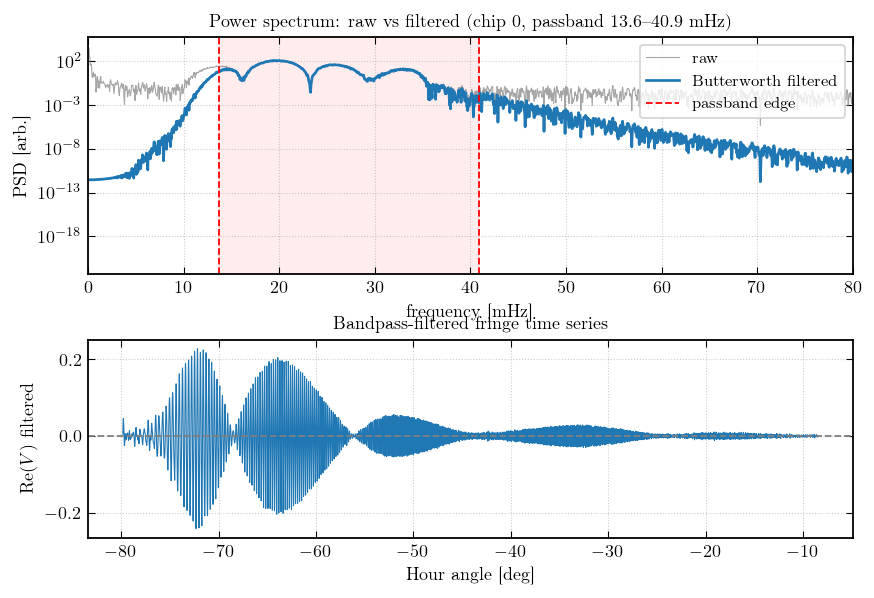

Total-power suppression by the bandpass filter: 2.3 dB
Passband: 13.6 – 40.9 mHz  (centre 27.3 mHz, BW frac = 0.5)
Zero-padded FFT length: 8192 (from 6445 samples)


In [12]:
# --- Power spectrum comparison: raw vs. Butterworth-filtered ---
from scipy.signal import get_window

# Hann window + zero-pad to next power of 2 for clean spectral leakage
n_sig = len(y_du)
n_fft = int(2 ** np.ceil(np.log2(n_sig)))  # zero-pad length
win = get_window("hann", n_sig)

# Windowed FFTs (normalised so that the PSD shape is meaningful)
Y_raw  = np.fft.rfft(y_du   * win, n=n_fft)
Y_filt = np.fft.rfft(y_filt * win, n=n_fft)
freqs  = np.fft.rfftfreq(n_fft, d=dt_d)  # Hz

# Power spectral density (|FFT|^2, arbitrary units — shape matters)
psd_raw  = np.abs(Y_raw)  ** 2
psd_filt = np.abs(Y_filt) ** 2

# --- Two-panel figure: top = PSD comparison, bottom = filtered time series ---
fig, axes = plt.subplots(2, 1, figsize=(TEXTWIDTH_IN, 5.0),
                         gridspec_kw={"height_ratios": [1.2, 1], "hspace": 0.30})

# -- Top panel: power spectra --
ax_psd = axes[0]
ax_psd.semilogy(freqs * 1e3, psd_raw, color=NEUTRAL_COLOR, lw=LW_FINE,
                alpha=0.7, label="raw")
ax_psd.semilogy(freqs * 1e3, psd_filt, color=CHIP_COLORS[ci_demo], lw=LW_STANDARD,
                label="Butterworth filtered")

# Mark filter passband edges
for f_edge, ls in [(flo, "--"), (fhi, "--")]:
    ax_psd.axvline(f_edge * 1e3, color="red", ls=ls, lw=LW_LIGHT,
                   label="passband edge" if f_edge == flo else None)

# Shade the passband
ax_psd.axvspan(flo * 1e3, fhi * 1e3, color="red", alpha=0.07)

ax_psd.set_xlabel("frequency [mHz]")
ax_psd.set_ylabel("PSD  [arb.]")
ax_psd.set_title(
    f"Power spectrum: raw vs filtered  (chip {ci_demo}, "
    f"passband {flo*1e3:.1f}–{fhi*1e3:.1f} mHz)",
    fontsize=TICK_SIZE,
)
ax_psd.legend(fontsize=TICK_SIZE - 1, loc="upper right")
ax_psd.set_xlim(0, min(80, freqs[-1] * 1e3))  # mHz

# -- Bottom panel: filtered time series (same as previous cell, for context) --
ax_ts = axes[1]
ax_ts.plot(ha_demo_du, y_filt, color=CHIP_COLORS[ci_demo], lw=LW_FINE)
ax_ts.axhline(0, color=NEUTRAL_COLOR, lw=LW_LIGHT, ls="--")
ax_ts.set_xlabel("Hour angle [deg]")
ax_ts.set_ylabel(r"Re$(V)$  filtered")
ax_ts.set_title("Bandpass-filtered fringe time series", fontsize=TICK_SIZE)

fig.tight_layout()
plt.show()

# Summary
noise_suppression = 10 * np.log10(
    np.sum(psd_raw[freqs > 0]) / np.sum(psd_filt[freqs > 0])
)
print(f"Total-power suppression by the bandpass filter: {noise_suppression:.1f} dB")
print(f"Passband: {flo*1e3:.1f} – {fhi*1e3:.1f} mHz  "
      f"(centre {f_c_demo*1e3:.1f} mHz, BW frac = {bw_frac})")
print(f"Zero-padded FFT length: {n_fft} (from {n_sig} samples)")

## 3.7 Bridge to notebooks 04 and 05

We've built three quantitative predictions and overlaid the lidar-prior model on the data. Each prediction is tested in a specific cell of a downstream notebook:

| Prediction (this notebook) | Tested by | Expected match if lidar prior is right |
|---|---|---|
| **P1** $P_f(0) \approx 26\;\mathrm{s}$ | nb 04: phase-slope, lag-spectrum, NLS, sliding-window FFT (fringe-frequency cell) | all five fitters agree on $b_{\mathrm{ew}}$ to within a few cm of 15.17 m, well inside the 30 cm lidar prior |
| **P2** four Bessel nulls in HA range | nb 05 §6.3: `find_bessel_zeros_in_envelope` should return ~4 nulls | exactly 4 nulls survive the prominence gating |
| **P3** first null at $\|u\| \approx 131\,\lambda$ | nb 05 §6.3: per-null table prints recovered $\|u\|$ | first row reads $\|u\| \approx 130\text{–}135\,\lambda$ |

If P1 matches, the **calibration step** (notebook 04) is consistent and we have a trustworthy $u$-axis. If P2 and P3 then also match, the **scientific measurements** (notebook 05) — the radio diameter and the sunspot residuals — sit on top of a verified geometric and astrophysical foundation, and the only remaining sources of bias are the well-characterised limb-brightening and chip-gain systematics enumerated in §1.6 / §8.1.

Concretely:

- **Forward model → calibration**. The point-source fringe model from §3.1 is the same model that the NLS fitter in nb 04 §4.5 fits to the data, with $(b_{\mathrm{ew}}, b_{\mathrm{ns}})$ as nonlinear parameters. The lidar prior is the seed.
- **Forward model → science**. The Bessel envelope from §3.2 is the same model that the diameter fitter in nb 05 §6.4 fits, with the disk radius $R$ as the nonlinear parameter. The recovered $R$ is the radio Sun radius — *the* result of the lab.

Move on to notebook 04 to do the calibration, and then to notebook 05 for the science.

**Takeaway.** If P1-P3 pass here, notebook 04 becomes a calibration exercise rather than a blind search, and notebook 05 inherits a trustworthy projected-baseline axis.
